In [1]:
import math
from datetime import timedelta

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from scipy.interpolate import griddata

import parcels
from parcels import StatusCode

## Parameters

In [2]:
lon_min = -29
lon_max = -22.5
lat_min = 14
lat_max = 19.5

refine_lon_fac = 5
refine_lat_fac = 5

integration_days = 10
integration_direction = -1
dt_minutes = 5
n_per_year = 73

date_freq = "5D"
date_start = "2025-01-01"
date_end   = "2025-12-31"

reference_times = pd.date_range(date_start, date_end, freq=date_freq)

output_zarr_path     = "../data/CV_FTLE_2025.zarr"
output_path = "../data/CV_FTLE_2025.nc"

In [3]:
flowfield_env = xr.open_dataset("../data/ssc.nc")
flowfield_env

/home/b/b384140/.conda/envs/parcels/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


<xarray.Dataset> Size: 2GB
Dimensions:    (time: 12199, latitude: 85, longitude: 109)
Coordinates:
    depth      float32 4B ...
  * latitude   (latitude) float32 340B 13.0 13.08 13.17 ... 19.83 19.92 20.0
  * longitude  (longitude) float32 436B -29.0 -28.92 -28.83 ... -20.08 -20.0
  * time       (time) datetime64[ns] 98kB 1993-01-01 1993-01-02 ... 2026-05-26
Data variables:
    uo         (time, latitude, longitude) float64 904MB ...
    vo         (time, latitude, longitude) float64 904MB ...
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574
    copernicusmarine_version:  2.4.1

## Boundary Conditions

In [4]:
# TODO: Let's implement with xr.where to be independent of numpy api
flowfield_env["uo"][:, :,  0] = 0.0
flowfield_env["uo"][:, :, -1] = 0.0
flowfield_env["uo"][:,  0, :] = 0.0
flowfield_env["uo"][:, -1, :] = 0.0
flowfield_env["vo"][:, :,  0] = 0.0
flowfield_env["vo"][:, :, -1] = 0.0
flowfield_env["vo"][:,  0, :] = 0.0
flowfield_env["vo"][:, -1, :] = 0.0

In [5]:
ocean_mask = flowfield_env.uo.mean("time").notnull().astype(float)

In [6]:
v_repel = 0.02

mask = ocean_mask.values
nj, ni = mask.shape
u_rep_arr = np.zeros((nj, ni))
v_rep_arr = np.zeros((nj, ni))

for j in range(1, nj - 1):
    for i in range(1, ni - 1):
        if mask[j, i] == 0:
            continue
        if mask[j,   i-1] == 0: u_rep_arr[j, i] += v_repel
        if mask[j,   i+1] == 0: u_rep_arr[j, i] -= v_repel
        if mask[j-1, i  ] == 0: v_rep_arr[j, i] += v_repel
        if mask[j+1, i  ] == 0: v_rep_arr[j, i] -= v_repel

In [7]:
u_repel = xr.DataArray(u_rep_arr, coords=ocean_mask.coords, dims=ocean_mask.dims)
v_repel_field = xr.DataArray(v_rep_arr, coords=ocean_mask.coords, dims=ocean_mask.dims)

In [8]:
flowfield_env["uo"] = flowfield_env.uo + u_repel
flowfield_env["vo"] = flowfield_env.vo + v_repel_field

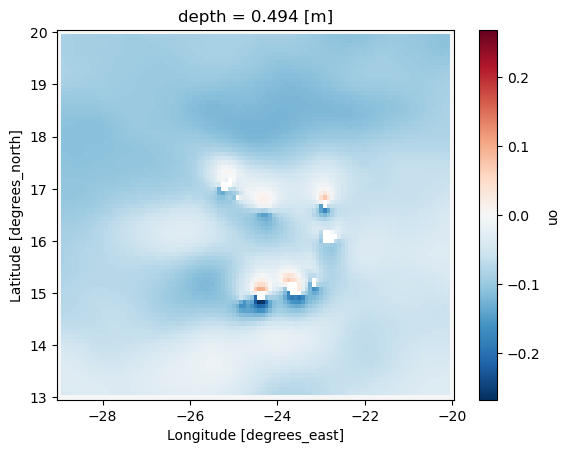

In [9]:
flowfield_env.uo.mean("time").plot()

## Parcels Fieldset

In [10]:
fieldset = parcels.FieldSet.from_xarray_dataset(
    flowfield_env,
    variables={"U": "uo", "V": "vo"},
    dimensions={"lon": "longitude", "lat": "latitude", "time": "time"},
)

In [11]:
particle_lon = xr.DataArray(
    data=np.linspace(
        flowfield_env.longitude.min().item(),
        flowfield_env.longitude.max().item(),
        refine_lon_fac * flowfield_env.sizes["longitude"] - 1
    ),
    name="plon",
    dims="plon",
)
particle_lat = xr.DataArray(
    data=np.linspace(
        flowfield_env.latitude.min().item(),
        flowfield_env.latitude.max().item(),
        refine_lat_fac * flowfield_env.sizes["latitude"] - 1
    ),
    name="plat",
    dims="plat",
)
particle_lon, particle_lat = xr.broadcast(particle_lon, particle_lat)

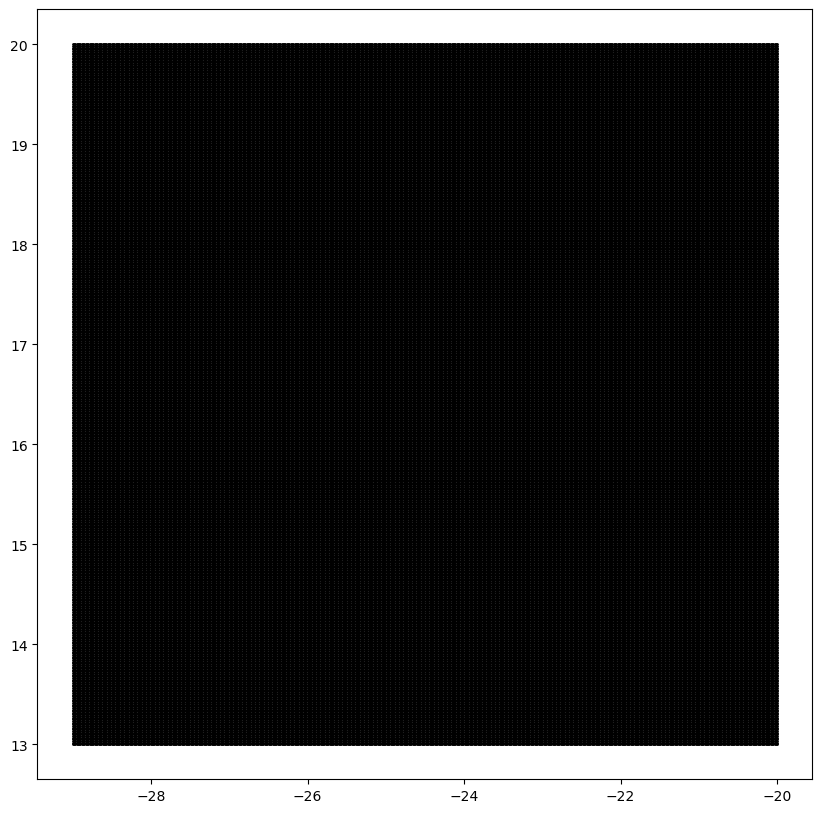

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.plot(particle_lon.values.ravel(), particle_lat.values.ravel(), "ko", markersize=1)
plt.show()

## Particle Advection and FTLE

In [13]:
def CheckOutOfBounds(particle, fieldset, time):
    if particle.state == StatusCode.ErrorOutOfBounds:
        particle.delete()

def CheckError(particle, fieldset, time):
    if particle.state >= 50:
        particle.delete()

In [14]:
n_particles = particle_lon.size
particle_ids = np.arange(n_particles)

In [15]:
def compute_ftle(fieldset, particle_lon, particle_lat, reference_time,
                  integration_days, integration_direction, dt_minutes):

    pset = parcels.ParticleSet.from_list(
        fieldset=fieldset,
        pclass=parcels.JITParticle,
        lon=particle_lon.stack(pid=["plon", "plat"]).load().data,
        lat=particle_lat.stack(pid=["plon", "plat"]).load().data,
        time=np.datetime64(reference_time),
        pid_orig=particle_ids,
    )

    initial_ids = np.asarray(pset.id, dtype=np.int64)
    id_base = initial_ids.min()

    kernels = (
        pset.Kernel(parcels.AdvectionRK4)
        + pset.Kernel(CheckOutOfBounds)
    )

    pset.execute(
        kernels,
        runtime=timedelta(days=integration_days),
        dt=timedelta(minutes=int(integration_direction * dt_minutes)),
    )

    surviving_index = np.asarray(pset.id, dtype=np.int64) - id_base

    lon_full = np.full(n_particles, np.nan)
    lat_full = np.full(n_particles, np.nan)
    lon_full[surviving_index] = pset.lon
    lat_full[surviving_index] = pset.lat

    n_lost = n_particles - surviving_index.size
    if n_lost:
        print(f"  {n_lost} / {n_particles} particles left the domain "
              f"({100 * n_lost / n_particles:.1f}%)")

    final_lon = (particle_lon.stack(pid=["plon", "plat"]) * 0 + lon_full).unstack()
    final_lat = (particle_lat.stack(pid=["plon", "plat"]) * 0 + lat_full).unstack()

    dX = (final_lon.shift(plon=-1) - final_lon.shift(plon=1)) * 111e3 * np.cos(np.deg2rad(final_lat))
    dx = (particle_lon.shift(plon=-1) - particle_lon.shift(plon=1)) * 111e3 * np.cos(np.deg2rad(particle_lat))

    dY = (final_lat.shift(plat=-1) - final_lat.shift(plat=1)) * 111e3
    dy = (particle_lat.shift(plat=-1) - particle_lat.shift(plat=1)) * 111e3

    F = np.array([
        [(dX/dx).stack(pid=["plon", "plat"]), (dX/dy).stack(pid=["plon", "plat"])],
        [(dY/dx).stack(pid=["plon", "plat"]), (dY/dy).stack(pid=["plon", "plat"])],
    ])

    valid = ~np.isnan(F).any(axis=(0, 1))
    F_clean = np.nan_to_num(F, nan=0.0)

    C   = np.einsum("kil,kjl->ijl", F_clean, F_clean)
    C_T = np.transpose(C, (2, 0, 1))
    eigenvalues, eigenvectors = np.linalg.eigh(C_T)
    eigenvalues[~valid, :] = np.nan

    max_eigenvalues = (np.max(eigenvalues, axis=1) + particle_lon.stack(pid=["plon", "plat"]) * 0).rename("lambda_plus").unstack()
    max_eigenvalues = max_eigenvalues.assign_coords(
        plon=particle_lon.isel(plat=0, drop=True),
        plat=particle_lat.isel(plon=0, drop=True),
    )

    T = integration_days * 24 * 60 * 60
    FTLE = (1 / (2 * T)) * np.log(np.maximum(max_eigenvalues, 1e-10))
    FTLE = FTLE.rename("FTLE")
    FTLE = FTLE.expand_dims(time=[np.datetime64(reference_time)])

    return FTLE

## Loop Over Reference Dates

In [16]:
ftle_list = []
for reference_time in reference_times:
    print(f"Computing FTLE for {reference_time.date()}")
    ftle_field = compute_ftle(
        fieldset, particle_lon, particle_lat,
        reference_time, integration_days, integration_direction, dt_minutes,
    )
    ftle_field = ftle_field.assign_coords(day=("time"))
    ftle_list.append(ftle_field)

ftle_timeseries = xr.concat(ftle_list, dim="time")
ftle_timeseries

Computing FTLE for 2025-01-01
100%|██████████| 864000.0/864000.0 [05:29<00:00, 2625.29it/s]
Computing FTLE for 2025-01-06
100%|██████████| 864000.0/864000.0 [05:30<00:00, 2614.25it/s]
Computing FTLE for 2025-01-11
100%|██████████| 864000.0/864000.0 [05:30<00:00, 2614.75it/s]
Computing FTLE for 2025-01-16
100%|██████████| 864000.0/864000.0 [05:28<00:00, 2627.63it/s]
Computing FTLE for 2025-01-21
100%|██████████| 864000.0/864000.0 [05:28<00:00, 2628.85it/s]
Computing FTLE for 2025-01-26
100%|██████████| 864000.0/864000.0 [05:29<00:00, 2623.55it/s]
Computing FTLE for 2025-01-31
100%|██████████| 864000.0/864000.0 [05:28<00:00, 2630.29it/s]
Computing FTLE for 2025-02-05
100%|██████████| 864000.0/864000.0 [05:29<00:00, 2625.21it/s]
Computing FTLE for 2025-02-10
100%|██████████| 864000.0/864000.0 [05:28<00:00, 2626.74it/s]
Computing FTLE for 2025-02-15
100%|██████████| 864000.0/864000.0 [05:29<00:00, 2618.38it/s]
Computing FTLE for 2025-02-20
100%|██████████| 864000.0/864000.0 [05:28<00:00, 2

<xarray.DataArray 'FTLE' (time: 73, plon: 544, plat: 424)> Size: 135MB
array([[[           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan, 1.37694880e-06, 1.88826019e-06, ...,
         2.01279097e-06, 2.47029630e-06,            nan],
        [           nan, 4.82827208e-07, 2.37177339e-07, ...,
         3.77092226e-06, 3.87497814e-06,            nan],
        ...,
        [           nan, 1.47818586e-07, 3.12052083e-07, ...,
         6.02042828e-07, 4.51529425e-07,            nan],
        [           nan, 2.85425565e-07, 3.76683652e-07, ...,
         5.55091921e-07, 4.54880927e-07,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan, 1.07843465e-06, 1.49679703e-06, ...,
         3.27829918e-06, 4.01352942e-06,            nan],
        [           nan, 3.98408973e-07, 3.08853496e-07, ...,
         2.45978147e-06, 4.01458351e-06,            nan],
...
         1.39812899e-07, 2.91206293e-07,            nan],
        [           nan, 2.84531374e-07, 3.94826088e-07, ...,
         7.76823275e-08, 1.15107428e-07,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan, 1.29668839e-06, 1.84331799e-06, ...,
         3.11294256e-06, 2.42310924e-06,            nan],
        [           nan, 6.62754107e-07, 7.36746561e-07, ...,
         1.63062047e-06, 1.86586074e-06,            nan],
        ...,
        [           nan, 2.79367264e-07, 4.45098761e-07, ...,
         1.64647461e-07, 2.64803061e-07,            nan],
        [           nan, 3.64720902e-07, 4.46128447e-07, ...,
         1.89180082e-07, 2.55346373e-07,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]]],
      shape=(73, 544, 424))
Coordinates:
  * time     (time) datetime64[us] 584B 2025-01-01 2025-01-06 ... 2025-12-27
  * plon     (plon) float64 4kB -29.0 -28.98 -28.97 ... -20.03 -20.02 -20.0
  * plat     (plat) float64 3kB 13.0 13.02 13.03 13.05 ... 19.97 19.98 20.0
    day      <U4 16B 'time'

In [17]:
ftle_timeseries.drop_encoding().to_dataset().to_zarr(output_zarr_path, mode="w")

In [18]:
ftle_timeseries.drop_encoding().to_netcdf(output_path)